## Imports and functions

In [12]:
import numpy as np
from numpy.fft import fftshift, fft, ifft, rfft, irfft, fftfreq
from numpy.typing import NDArray
import json
from pathlib import Path
from scipy.constants import speed_of_light as C_MKS
import pandas as pd
from copy import deepcopy
import matplotlib.pyplot as plt
from lmfit.models import ConstantModel, Model
from scipy.constants import Boltzmann as kB
from scipy.constants import speed_of_light as c
from scipy.constants import atomic_mass as au
from scipy.constants import epsilon_0 as e0
from scipy.constants import hbar
from scipy.special import voigt_profile
from scipy.signal import find_peaks

def pressure_torr(temp_K: float) -> float:
    if temp_K < 39.31:
        logp = - 94.04826 - 1961.258 / temp_K - \
            0.03771687 * temp_K + 42.57526 * np.log10(temp_K)
    else:
        logp = 15.88253 - 4529.635 / temp_K + 0.00058663 * \
            temp_K - 2.99138 * np.log10(temp_K)
    return 10 ** logp

def transmission_model(x, center, amplitude, sigma, gamma):
    absorption = amplitude * voigt_profile((x-center), sigma, gamma)
    return np.nan_to_num(np.exp(-absorption), nan=0)

def number_density(temp_K: float) -> float:
    return 133.323 * pressure_torr(temp_K) / (kB * temp_K)

def load_avg_pug_bin(path: Path) -> NDArray[np.complex128]:
    """
    Loads and averages all data files under the pug directory.

    Args:
        path (Path): Path to the directory containing the .bin files, typ. 
        'Channel1'.

    Returns:
        NDArray[np.complex128]: Averaged and carrier-offset interferogram.
    """
    data_files = path.glob('*.bin')
    data_list = []
    for fname in data_files:
        data_list.append(load_pug_bin(fname))

    # Handle different lengths by padding with NaN
    max_len = max(len(d) for d in data_list)
    matrix = np.full((max_len, len(data_list)), np.nan, dtype=complex)

    for i, d in enumerate(data_list):
        matrix[:len(d), i] = d

    # Compute average across files (ignoring NaNs for uneven lengths)
    avg_signal = np.nanmean(matrix, axis=1)
    return avg_signal

def load_pug_bin(path: Path) -> NDArray[np.complex128]:
    """
    Loads a single .bin file in the method used by the PUG.

    Args:
        path (Path): Path to the .bin file.

    Returns:
        NDArray[np.complex128]: Carrier-subtracted interferogram.
    """
    # Load raw binary floats (32-bit)
    numbers = np.fromfile(path, dtype=np.float32)

    # Convert to complex: (real, imag) pairs
    complex_data = numbers[0::2] + 1j * numbers[1::2]
    return complex_data

def load_json(path: Path) -> dict:
    """
    Loads a .json file as a dictionary.

    Args:
        path (Path): Path to .json file.

    Returns:
        dict: Contents of the file.
    """
    with open(path, 'r') as f:
        return json.load(f)                                                        

def load_pug(path) -> tuple[dict, NDArray] | tuple[None, None]:
    """
    Opens a dialog to ask the user for the PUG's data directory. Loads data exported from the PUG.

    Returns:
        tuple[dict, NDArray]|tuple[None,None]: A parameter dictionary and a complex,
        averaged data array. Returns None for both if the dialog is canceled.
    """
    apriori = load_json(path / 'apriori_params.json')
    computed =load_json(path / 'computed_params.json')
    gage = load_json(path / 'gageCard_params.json')
    avg_data = load_avg_pug_bin(path / 'Output_data/Channel1')
    params = {}
    params.update(apriori)
    params.update(computed)
    params.update(gage)
    return params, avg_data

def calc_absorbance(spectrum):
    """
    Calculates the absorbance of the spectrum and updates internal variables.
    """

    return - np.log(spectrum) 

def calc_cepstral_modified_igm(absorbance, optical_axis, time_axis, freq_cuton: float, freq_cutoff: float): 
    """
    Calculates the modified igm based on the absorbance and updates internal values for
    it and the associated time and frequency axes.

    Args:
        freq_cuton (flaot): Start of the absorbance window 
        freq_cutoff (float): End of the absorbance window
    """
    # Cut axis and absorbance based on window bounds
    mask = (optical_axis >= freq_cuton) & (optical_axis <= freq_cutoff)
    cepstral_optical_axis = optical_axis[mask]
    absorbance_cut = absorbance[mask]

    # Calculate modified igm
    # mod_igm = irfft(absorbance_cut)
    mod_igm = ifft(absorbance_cut)

    # Calculate time axis
    cep_time_axis = np.linspace(
        time_axis[0], time_axis[-1], len(mod_igm))

    # Update internal variables
    cepstral_time_axis = cep_time_axis
    mod_igm = mod_igm
    return mod_igm, cepstral_optical_axis, cepstral_time_axis

def calc_cepstral_spectrum(mod_igm, cep_time_axis, time_cutons: float, time_cutoffs:float, filter='step'):
    """
    Calculates the background-subtracted spectrum and updates internal variables.

    Args:
        time_cutons (float): Start of 
        time_cutoffs (float): _description_
        filter (str, optional): _description_. Defaults to 'step'.

    Raises:
        ValueError: _description_
    """        
    if not isinstance(time_cutons, (list, tuple)):
        cutons = [time_cutons]
    else:
        cutons = time_cutons

    if not isinstance(time_cutoffs, (list, tuple)):
        cutoffs = [time_cutoffs]
    else:
        cutoffs = time_cutoffs


    for cuton, cutoff in zip(cutons, cutoffs):
        if filter == 'step':
            mask = (cep_time_axis >= cuton) & (cep_time_axis <= cutoff)
            mod_igm[mask] = 0
        else:
            raise ValueError(
                f'\"{filter}\" is not a valid input for argument filter')

    # cepstral_absorbance = -rfft(mod_igm)
    cepstral_absorbance = -fft(mod_igm)
    return np.abs(np.exp(cepstral_absorbance))  

def alias_frequency(f0, df, fs):
    """
    Compute the aliased frequency of a signal after shifting.

    Parameters:
        f0 : float
            Initial frequency (Hz)
        df : float
            Frequency shift applied before sampling (Hz)
        fs : float
            Sampling rate (Hz)

    Returns:
        float: Aliased frequency (Hz), in range [-fs/2, fs/2)
    """
    f = f0 + df
    return ((f + fs/2) % fs) - fs/2


## Data and Parameters (Steck)

In [3]:
# Experimental parameters
temp_K = 273+40 
B_field_gauss = .3
cell_length = .075

mass_85 = au * 84.911789732
mass_87 = au * 86.909180520

ratio_85 = .7217
ratio_87 = 1- ratio_85

nuc_spin_degen_85 = 12
nuc_spin_degen_87 = 8

nu0_D1_85 = 377.10738569e12
nu0_D2_85 = 384.23040637e12

nu0_D1_87 = 377.1074635e12
nu0_D2_87 = 384.2304844685e12

Gamma_D1 = 2 * np.pi * 5.746e6
Gamma_D2 = 2 * np.pi * 6.065e6

lam_D1 = 794.979e-9
lam_D2 = 780.241e-9

dop_sigmav_85 = np.sqrt(kB * temp_K / mass_85) 
dop_sigmav_87 = np.sqrt(kB * temp_K / mass_87)

dipole_mat_element_D1 = 3 * \
    np.sqrt(e0 * hbar * Gamma_D1 * lam_D1**3 / (8 * np.pi**2))
dipole_mat_element_D2 = 3 * \
    np.sqrt(e0 * hbar * Gamma_D2 * lam_D2**3 / (8 * np.pi**2))

# D2 dict

isotopes = {'85': {}, '87': {}}
lines = {'D1': deepcopy(isotopes), 'D2': deepcopy(isotopes)}

lines['D1']['87']['Fg2Fe1'] = {'center': nu0_D1_87 - 2.5630059790891e9 -510.410e6 - .7e6 * B_field_gauss + .23e6 * B_field_gauss, 'cf2': 5/18}
lines['D1']['87']['Fg2Fe2'] = {'center': nu0_D1_87 - 2.5630059790891e9 +306.246e6 - .7e6 * B_field_gauss + .23e6 * B_field_gauss, 'cf2': 5/18}

lines['D1']['85']['Fg3Fe2'] = {'center': nu0_D1_85 - 1.2648885163e9 -210.923e6 -.47e6 * B_field_gauss -.16e6 * B_field_gauss, 'cf2': 35/81}
lines['D1']['85']['Fg3Fe3'] = {'center': nu0_D1_85 - 1.2648885163e9 + 150.659e6 -.47e6 * B_field_gauss +.16e6 * B_field_gauss, 'cf2': 28/81}

lines['D1']['85']['Fg2Fe2'] = {'center': nu0_D1_85 + 1.7708439228e9 -210.923e6+.47e6 * B_field_gauss -.16e6 * B_field_gauss, 'cf2': 10/81}
lines['D1']['85']['Fg2Fe3'] = {'center': nu0_D1_85 + 1.7708439228e9 + 150.659e6+.47e6 * B_field_gauss +.16e6 * B_field_gauss, 'cf2': 35/81}

lines['D1']['87']['Fg1Fe1'] = {'center': nu0_D1_87 + 4.2716766318151e9 -510.410e6 + .7e6 * B_field_gauss +.23e6 * B_field_gauss, 'cf2': 1/18}
lines['D1']['87']['Fg1Fe2'] = {'center': nu0_D1_87  +4.2716766318151e9+306.246e6+ .7e6 * B_field_gauss +.23e6 * B_field_gauss, 'cf2': 5/18}

lines['D2']['87']['Fg2Fe1'] = {'center': nu0_D2_87 - 2.56300597908911e9 -229.8518e6 -.7e6 * B_field_gauss +.93e6 * B_field_gauss, 'cf2': 1/18}
lines['D2']['87']['Fg2Fe2'] = {'center': nu0_D2_87 - 2.56300597908911e9- 72.9113e6 -.7e6 * B_field_gauss +.93e6 * B_field_gauss, 'cf2': 5/18}
lines['D2']['87']['Fg2Fe3'] = {'center': nu0_D2_87  - 2.56300597908911e9+193.7408e6 -.7e6 * B_field_gauss +.93e6 * B_field_gauss, 'cf2': 7/9}

lines['D2']['85']['Fg3Fe2'] = {'center': nu0_D2_85 - 1.264888516e9 -83.955e6  -.47e6 * B_field_gauss +.16e6* B_field_gauss, 'cf2': 10/81}
lines['D2']['85']['Fg3Fe3'] = {'center': nu0_D2_85 - 1.264888516e9 - 20.503e6 -.47e6 * B_field_gauss +.54e6* B_field_gauss, 'cf2': 35/81}
lines['D2']['85']['Fg3Fe4'] = {'center': nu0_D2_85 - 1.264888516e9+ 100.357e6 -.47e6 * B_field_gauss +.70e6* B_field_gauss, 'cf2': 1}

lines['D2']['85']['Fg2Fe1'] = {'center': nu0_D2_85 +1.770843922e9 -113.307e6 +.47e6 * B_field_gauss -1.4e6 * B_field_gauss, 'cf2': 1/3}
lines['D2']['85']['Fg2Fe2'] = {'center': nu0_D2_85 +1.770843922e9-83.955e6+.47e6 * B_field_gauss +.16e6 * B_field_gauss, 'cf2': 35/81}
lines['D2']['85']['Fg2Fe3'] = {'center': nu0_D2_85 +1.770843922e9- 20.503e6+.47e6 * B_field_gauss +.54e6 * B_field_gauss, 'cf2': 28/81}

lines['D2']['87']['Fg1Fe0'] = {'center': nu0_D2_87 +4.27167663181519e9 -302.0738e6 +.7e6 * B_field_gauss, 'cf2': 1/9}
lines['D2']['87']['Fg1Fe1'] = {'center': nu0_D2_87 +4.27167663181519e9-229.8518e6+.7e6 * B_field_gauss+.93e6 * B_field_gauss, 'cf2': 5/18}
lines['D2']['87']['Fg1Fe2'] = {'center': nu0_D2_87 +4.27167663181519e9 - 72.9113e6+.7e6 * B_field_gauss+.93e6 * B_field_gauss, 'cf2': 5/18}

for line, isotopes in lines.items():
    for isotope, transitions in isotopes.items():
        for transition, props in transitions.items():
            if isotope == '85':
                if line == 'D2':
                    props['sigma'] = dop_sigmav_85 * nu0_D2_85 / c
                    props['gamma'] = Gamma_D2/2
                    props['absorption'] = props['cf2'] * dipole_mat_element_D2 ** 2 * ratio_85 * \
                        number_density(
                            temp_K) / (nuc_spin_degen_85 * hbar * e0 * dop_sigmav_85)
                    # props['absorption'] = props['cf2'] * dipole_mat_element_D2 ** 2 * \
                        # number_density(
                            # temp_K) / (nuc_spin_degen_85 * hbar * e0 * dop_sigmav_85)
                elif line == 'D1':
                    props['sigma'] = dop_sigmav_85 * nu0_D1_85 / c
                    props['gamma'] = Gamma_D1/2
                    props['absorption'] = props['cf2'] * dipole_mat_element_D1 ** 2 * ratio_85 * \
                        number_density(
                            temp_K) / (nuc_spin_degen_85 * hbar * e0 * dop_sigmav_85)
                    # props['absorption'] = props['cf2'] * dipole_mat_element_D1 ** 2 * \
                        # number_density(
                            # temp_K) / (nuc_spin_degen_85 * hbar * e0 * dop_sigmav_85)
            elif isotope == '87':
                if line == 'D2':
                    props['sigma'] = dop_sigmav_87 * nu0_D2_87 / c
                    props['gamma'] = Gamma_D2/2
                    props['absorption'] = props['cf2'] * dipole_mat_element_D2 ** 2 * ratio_87 * \
                        number_density(
                            temp_K) / (nuc_spin_degen_87 * hbar * e0 * dop_sigmav_87)
                    # props['absorption'] = props['cf2'] * dipole_mat_element_D2 ** 2 * \
                        # number_density(
                            # temp_K) / (nuc_spin_degen_87 * hbar * e0 * dop_sigmav_87)
                elif line == 'D1':
                    props['sigma'] = dop_sigmav_87 * nu0_D1_87 / c
                    props['gamma'] = Gamma_D1/2
                    props['absorption'] = props['cf2'] * dipole_mat_element_D1 ** 2 * ratio_87 * \
                        number_density(
                            temp_K) / (nuc_spin_degen_87 * hbar * e0 * dop_sigmav_87)
                    # props['absorption'] = props['cf2'] * dipole_mat_element_D1 ** 2 * \
                        # number_density(
                            # temp_K) / (nuc_spin_degen_87 * hbar * e0 * dop_sigmav_87)


## Data and parameters (Siddons)

In [2]:
# Experimental parameters
temp_K = 273+30 
cell_length = .075

mass_85 = au * 84.911789732
mass_87 = au * 86.909180520

ratio_85 = .7217
ratio_87 = .2783

nuc_spin_degen_85 = 12
nuc_spin_degen_87 = 8

nu0_D1 = 377107407.299e6
nu0_D2 = 384230426.6e6

Gamma_D1 = 2 * np.pi * 5.746e6
Gamma_D2 = 2 * np.pi * 6.065e6

lam_D1 = 794.979e-9
lam_D2 = 780.241e-9

dop_sigmav_85 = np.sqrt(kB * temp_K / mass_85) 
dop_sigmav_87 = np.sqrt(kB * temp_K / mass_87)

dipole_mat_element_D1 = 3 * \
    np.sqrt(e0 * hbar * Gamma_D1 * lam_D1**3 / (8 * np.pi**2))
dipole_mat_element_D2 = 3 * \
    np.sqrt(e0 * hbar * Gamma_D2 * lam_D2**3 / (8 * np.pi**2))

# D2 dict

isotopes = {'85': {}, '87': {}}
lines = {'D1': deepcopy(isotopes), 'D2': deepcopy(isotopes)}

lines['D1']['87']['Fg2Fe1'] = {'center': nu0_D1 - 3014.644e6, 'cf2': 5/18}
lines['D1']['87']['Fg2Fe2'] = {'center': nu0_D1 - 2202.381e6, 'cf2': 5/18}

lines['D1']['85']['Fg3Fe2'] = {'center': nu0_D1 - 1497.657e6, 'cf2': 35/81}
lines['D1']['85']['Fg3Fe3'] = {'center': nu0_D1 - 1135.721e6, 'cf2': 28/81}

lines['D1']['85']['Fg2Fe2'] = {'center': nu0_D1 + 1538.063e6, 'cf2': 10/81}
lines['D1']['85']['Fg2Fe3'] = {'center': nu0_D1 + 1900.087e6, 'cf2': 35/81}

lines['D1']['87']['Fg1Fe1'] = {'center': nu0_D1 + 3820.046e6, 'cf2': 1/18}
lines['D1']['87']['Fg1Fe2'] = {'center': nu0_D1 + 4632.339e6, 'cf2': 5/18}

lines['D2']['87']['Fg2Fe1'] = {'center': nu0_D2 - 2735.05e6, 'cf2': 1/18}
lines['D2']['87']['Fg2Fe2'] = {'center': nu0_D2 - 2578.11e6, 'cf2': 5/18}
lines['D2']['87']['Fg2Fe3'] = {'center': nu0_D2 - 2311.26e6, 'cf2': 7/9}

lines['D2']['85']['Fg3Fe2'] = {'center': nu0_D2 - 1371.29e6, 'cf2': 10/81}
lines['D2']['85']['Fg3Fe3'] = {'center': nu0_D2 - 1307.87e6, 'cf2': 35/81}
lines['D2']['85']['Fg3Fe4'] = {'center': nu0_D2 - 1186.91e6, 'cf2': 1}

lines['D2']['85']['Fg2Fe1'] = {'center': nu0_D2 + 1635.454e6, 'cf2': 1/3}
lines['D2']['85']['Fg2Fe2'] = {'center': nu0_D2 + 1664.714e6, 'cf2': 35/81}
lines['D2']['85']['Fg2Fe3'] = {'center': nu0_D2 + 1728.134e6, 'cf2': 28/81}

lines['D2']['87']['Fg1Fe0'] = {'center': nu0_D2 + 4027.403e6, 'cf2': 1/9}
lines['D2']['87']['Fg1Fe1'] = {'center': nu0_D2 + 4099.625e6, 'cf2': 5/18}
lines['D2']['87']['Fg1Fe2'] = {'center': nu0_D2 + 4256.57e6, 'cf2': 5/18}

for line, isotopes in lines.items():
    for isotope, transitions in isotopes.items():
        for transition, props in transitions.items():
            if isotope == '85':
                if line == 'D2':
                    props['sigma'] = dop_sigmav_85 * nu0_D2 / c
                    props['gamma'] = Gamma_D2/2
                    props['absorption'] = props['cf2'] * dipole_mat_element_D2 ** 2 * ratio_85 * \
                        number_density(
                            temp_K) / (nuc_spin_degen_85 * hbar * e0 * dop_sigmav_85)
                elif line == 'D1':
                    props['sigma'] = dop_sigmav_85 * nu0_D1 / c
                    props['gamma'] = Gamma_D1/2
                    props['absorption'] = props['cf2'] * dipole_mat_element_D1 ** 2 * ratio_85 * \
                        number_density(
                            temp_K) / (nuc_spin_degen_85 * hbar * e0 * dop_sigmav_85)
            elif isotope == '87':
                if line == 'D2':
                    props['sigma'] = dop_sigmav_87 * nu0_D2 / c
                    props['gamma'] = Gamma_D2/2
                    props['absorption'] = props['cf2'] * dipole_mat_element_D2 ** 2 * ratio_87 * \
                        number_density(
                            temp_K) / (nuc_spin_degen_87 * hbar * e0 * dop_sigmav_87)
                elif line == 'D1':
                    props['sigma'] = dop_sigmav_87 * nu0_D1 / c
                    props['gamma'] = Gamma_D1/2
                    props['absorption'] = props['cf2'] * dipole_mat_element_D1 ** 2 * ratio_87 * \
                        number_density(
                            temp_K) / (nuc_spin_degen_87 * hbar * e0 * dop_sigmav_87)

## Cepstral 

In [24]:
# path = Path(r"C:\Users\mike\Documents\School\Research\Diddams\data\20251030_15h49m14s")
# path = Path(r"C:\Users\mike\Documents\School\Research\Diddams\data\20251023_10h18m12s")
path = Path(r"/home/mike/Documents/Boulder_PhD/Data/20251030_15h49m14s")
comppath = path / 'rb_cepstral.csv'
comp_data = pd.read_csv(comppath)

params, avg_signal = load_pug(path)

1934050 100000031.92 100000000
3021954
3.0
Axis norm [-0.5        -0.49999967 -0.49999934 ...  0.49999901  0.49999934
  0.49999967]
Axis N [-1510977. -1510976. -1510975. ...  1510974.  1510975.  1510976.]
Shift 386810353469847.75
[2.35712605e+14 2.35712705e+14 2.35712805e+14 ... 5.37907802e+14
 5.37907902e+14 5.37908002e+14]
377097407299000.0 384240426600000.0
[5.37000171e+10 5.37000171e+10 5.37000171e+10 ... 5.37000171e+10
 5.37000171e+10 5.37000171e+10]


/tmp/ipykernel_1165703/4011509953.py:61: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  f.show()


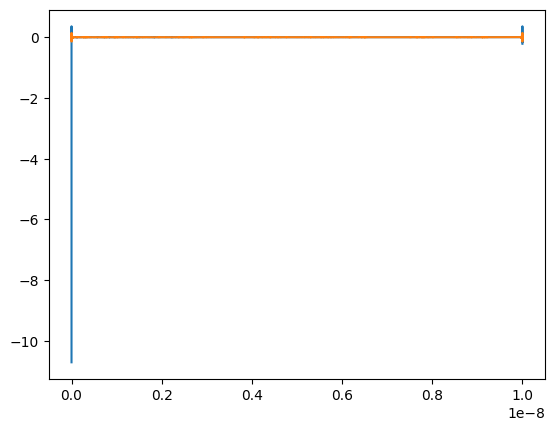

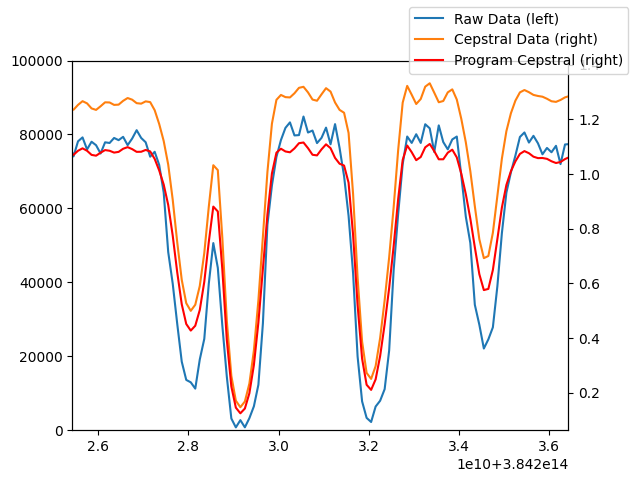

In [25]:
fb1 = -36e6
fb2 = 27e6
f01 = -35e6
f02 = -36e6
fr1 = params['fr_approx_Hz']
dfr = params['dfr']
sample_rate = params['sampling_rate_Hz']
nu_cw = C_MKS / params['reference1_laser_wvl_nm'] * 1e9
cw_mode1 = round((nu_cw + fb1 - f01) / fr1)
print(cw_mode1, fr1, sample_rate)
harmonic = params['nb_harmonic']
extra_ref_slope_factor = params['extra_ref_slope_factor']

comparison_axis = comp_data['Optical Axis (Hz)'].to_numpy()
comparison_spectrum = comp_data[' Real Spectrum'].to_numpy()

ppigm = len(avg_signal)
print(ppigm)

electrical_freq_cw_tooth_true = alias_frequency((fb1 - fb2)*harmonic, 0, fr1 + dfr)
electrical_freq_cw_tooth_sampled = alias_frequency((fb1 - fb2+ extra_ref_slope_factor * sample_rate / 2/ np.pi)*harmonic, 0, sample_rate)
ntooth_shift =  np.round(np.abs(electrical_freq_cw_tooth_sampled - electrical_freq_cw_tooth_true)/dfr) 
print(ntooth_shift)

axis_norm = fftshift(fftfreq(ppigm))
axis_N = axis_norm * ppigm
axis_shift = harmonic * ((cw_mode1) * fr1 + f01) + 3 * fr1 
print("Axis norm", axis_norm)
print("Axis N", axis_N)
print("Shift", axis_shift)
# Still need to derive extra mode offset
raw_optical_axis = (axis_N ) * fr1 + axis_shift
print(raw_optical_axis)

raw_spectrum = np.abs(fftshift(fft(avg_signal)))

absorbance = calc_absorbance(raw_spectrum)

time_axis = np.linspace(0, 1/ sample_rate, ppigm)
freq_cuton, freq_cutoff = (nu0_D1- 10e9, nu0_D2 + 10e9)
print(freq_cuton,freq_cutoff)
mod_igm, cepstral_optical, cepstral_time = calc_cepstral_modified_igm(absorbance, raw_optical_axis, time_axis, freq_cuton, freq_cutoff)

time_cutons, time_cutoffs = ([0, 2e-9], [1e-11 ,1/sample_rate])
cepstral_spectrum_full = calc_cepstral_spectrum(np.copy(mod_igm), cepstral_time, time_cutons, time_cutoffs)
plt.plot(cepstral_time, np.real(mod_igm))
plt.plot(cepstral_time, np.imag(mod_igm))
# Plot comparison
f, ax = plt.subplots()
ax2 = plt.twinx()
ax.plot(raw_optical_axis, raw_spectrum, color='tab:blue', label="Raw Data (left)")
# ax2.plot(peak_axis, unshift_spectrum, 'r-', label='Model (right)')
ax2.plot(cepstral_optical, cepstral_spectrum_full, color='tab:orange', label='Cepstral Data (right)')
ax2.plot(comparison_axis, comparison_spectrum, color='r', label='Program Cepstral (right)')
print(cepstral_optical-comparison_axis[:len(cepstral_optical)])
ax.set_xlim(nu0_D2 - 5e9, nu0_D2 + 6e9)
# ax.set_xlim(nu0_D2 + 9e9, nu0_D2 + 11e9)
ax.set_ylim(0, 1e5)
# ax.set_ylim(0, 5e5)
f.legend()
f.show()


## Fit D2s

[[Model]]
    ((((((((((((Model(constant, prefix='bkg_') * Model(transmission_model, prefix='v_Fg3Fe2_85')) * Model(transmission_model, prefix='v_Fg3Fe3_85')) * Model(transmission_model, prefix='v_Fg3Fe4_85')) * Model(transmission_model, prefix='v_Fg2Fe1_85')) * Model(transmission_model, prefix='v_Fg2Fe2_85')) * Model(transmission_model, prefix='v_Fg2Fe3_85')) * Model(transmission_model, prefix='v_Fg2Fe1_87')) * Model(transmission_model, prefix='v_Fg2Fe2_87')) * Model(transmission_model, prefix='v_Fg2Fe3_87')) * Model(transmission_model, prefix='v_Fg1Fe0_87')) * Model(transmission_model, prefix='v_Fg1Fe1_87')) * Model(transmission_model, prefix='v_Fg1Fe2_87'))
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 34
    # data points      = 120
    # variables        = 3
    chi-square         = 0.01087599
    reduced chi-square = 9.2957e-05
    Akaike info crit   = -1111.04274
    Bayesian info crit = -1102.68026
    R-squared          = 0.99796720
[[Variables]]

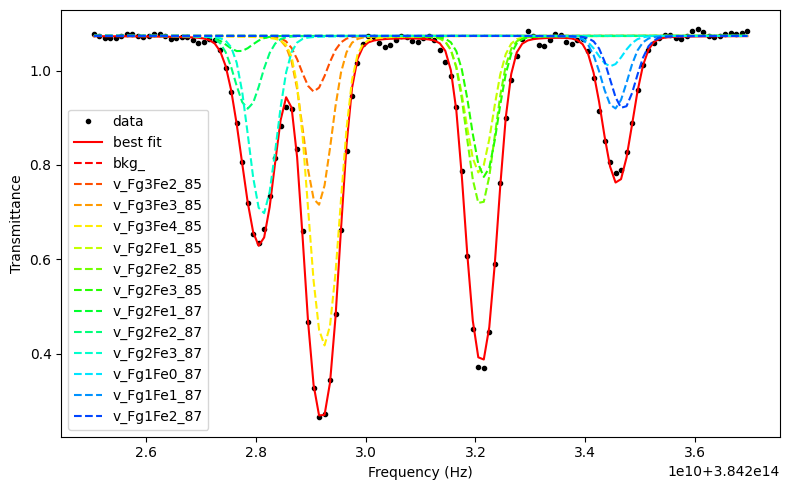

[3.84228052e+14 3.84229152e+14 3.84232052e+14 3.84234552e+14]
[0.62825717 0.26697447 0.3895738  0.7617444 ]


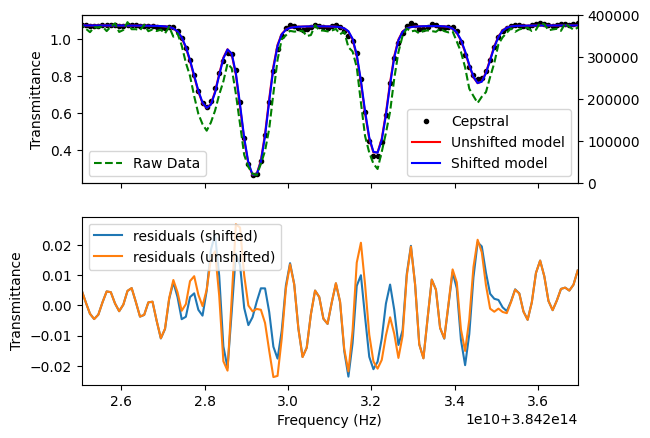

In [43]:
# D2 Fits ######################################3

mask = (cepstral_optical >= 384.225e12) & (cepstral_optical <= 384.237e12)
cepstral_axis = cepstral_optical[mask] 
cepstral_spectrum = cepstral_spectrum_full.copy()
cepstral_spectrum = cepstral_spectrum[mask]
# ---------------------------
# Build composite Voigt model
# ---------------------------
model = ConstantModel(prefix='bkg_')  # background offset
params = model.make_params()

params['bkg_c'].set(value=1)
params.add('xoffset', value=0, min=-500e6, max=500e6)
params.add('amp_scale', value=1e9)
# params.add('Rb87_ratio', value=ratio_87, max=ratio_87+.1, min=ratio_87-.1)

for isotope, transitions in lines['D2'].items():
    for transition, props in transitions.items():
        prefix = f'v_{transition + '_' + isotope}'
        m = Model(transmission_model, prefix=prefix)
        model *= m
        params.update(m.make_params())

        # Give reasonable starting guesses
        params.add(f'{prefix}amp_rel', value=props['absorption'], vary=False)
        params[f'{prefix}sigma'].set(value=props['sigma'], vary=False)
        params[f'{prefix}gamma'].set(value=props['gamma'], vary=False)
        params.add(f'{prefix}center_rel', value=props['center'], vary=False)
        params[f'{prefix}center'].expr = f'{prefix}center_rel + xoffset'
        params[f'{prefix}amplitude'].expr = f'{prefix}amp_rel * amp_scale'

# ---------------------------
# Fit model to data
# ---------------------------
result = model.fit(cepstral_spectrum, params, x=cepstral_axis)

shifted_model = result.best_fit
# ---------------------------
# Display results
# ---------------------------
print(result.fit_report())

plt.figure(figsize=(8, 5))
plt.plot(cepstral_axis, cepstral_spectrum, 'k.', label='data')
plt.plot(cepstral_axis, shifted_model, 'r-', label='best fit')

# Plot each individual component
cmap = plt.colormaps['hsv']
colors = cmap(np.linspace(0, 1, 20))
components = result.eval_components(x=cepstral_axis)
yoffset = components['bkg_']
for i, x in enumerate(components.items()):
    name = x[0]
    comp = x[1]
    if i==0:
        plt.plot(cepstral_axis, np.real(comp) , '--', label=name, color=colors[i])
    else:
        plt.plot(cepstral_axis, np.real(comp) *yoffset, '--', label=name, color=colors[i])

plt.xlabel('Frequency (Hz)')
plt.ylabel('Transmittance')
plt.legend()
plt.tight_layout()
plt.show()

# Unshifted line peaks
# model_axis = np.linspace(np.min(axis), np.max(axis), int(1e6))
model_axis = cepstral_axis
unshift_params = result.params.copy()
unshift_params['xoffset'].set(value=0)
unshifted_model = result.eval(x=model_axis, params=unshift_params)

peaks_idx, peaks_props = find_peaks(-unshifted_model)
peaks_freq = np.array([model_axis[idx] for idx in peaks_idx])
peaks_amp = result.eval(x=peaks_freq, params=unshift_params)
print(peaks_freq)
print(peaks_amp)
f, axs = plt.subplots(2,1, sharex=True)
axs[0].plot(cepstral_axis, cepstral_spectrum, 'k.', label='Cepstral')
axs[0].plot(model_axis, unshifted_model, 'r-', label='Unshifted model')
axs[0].plot(model_axis, shifted_model, 'b-', label='Shifted model')
twinax = axs[0].twinx()
twinax.plot(raw_optical_axis, raw_spectrum, 'g--', label='Raw Data')
axs[1].plot(cepstral_axis, cepstral_spectrum- shifted_model, label = 'residuals (shifted)')
axs[1].plot(cepstral_axis, cepstral_spectrum- unshifted_model, label = 'residuals (unshifted)')
# plt.plot(peaks_freq, peaks_amp, 'b.', label = 'peaks')
axs[1].set_xlabel('Frequency (Hz)')
axs[0].set_ylabel('Transmittance')
axs[1].set_ylabel('Transmittance')
axs[0].set_xlim(min(model_axis), max(model_axis))
twinax.set_ylim(0,4e5)
axs[0].legend()
axs[1].legend()
twinax.legend()
plt.show()


## Fit D1s

[[Model]]
    ((((((((Model(constant, prefix='bkg_') * Model(transmission_model, prefix='v_Fg3Fe2_85')) * Model(transmission_model, prefix='v_Fg3Fe3_85')) * Model(transmission_model, prefix='v_Fg2Fe2_85')) * Model(transmission_model, prefix='v_Fg2Fe3_85')) * Model(transmission_model, prefix='v_Fg2Fe1_87')) * Model(transmission_model, prefix='v_Fg2Fe2_87')) * Model(transmission_model, prefix='v_Fg1Fe1_87')) * Model(transmission_model, prefix='v_Fg1Fe2_87'))
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 34
    # data points      = 110
    # variables        = 3
    chi-square         = 0.10852121
    reduced chi-square = 0.00101422
    Akaike info crit   = -755.341899
    Bayesian info crit = -747.240458
    R-squared          = 0.89157192
[[Variables]]
    bkg_c:                  1.02422682 +/- 0.00378966 (0.37%) (init = 1)
    xoffset:                23594237.4 +/- 12239067.6 (51.87%) (init = 0)
    amp_scale:              37310952.5 +/- 1377734.57 (3.69%

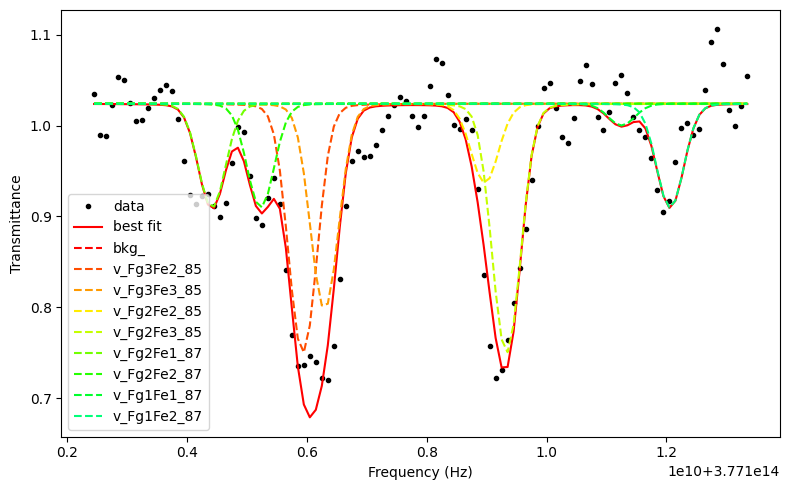

[3.7710435e+14 3.7710525e+14 3.7710605e+14 3.7710925e+14 3.7711125e+14
 3.7711205e+14]
[0.91025657 0.90391633 0.67907818 0.73050573 0.9988929  0.90938569]


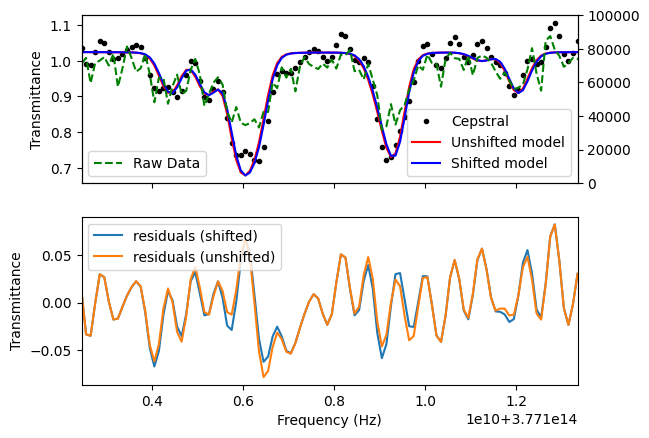

In [46]:
mask = (cepstral_optical>= nu0_D1 - 5e9) & (cepstral_optical<= nu0_D1 + 6e9) 
cepstral_axis = cepstral_optical[mask]
cepstral_spectrum = cepstral_spectrum_full.copy()
cepstral_spectrum = cepstral_spectrum[mask]
# ---------------------------
# Build composite Voigt model
# ---------------------------
model = ConstantModel(prefix='bkg_')  # background offset
params = model.make_params()

params['bkg_c'].set(value=1)
params.add('xoffset', value=0, min=-500e6, max=500e6)
params.add('amp_scale', value=1e9)

for isotope, transitions in lines['D1'].items():
    for transition, props in transitions.items():
        prefix = f'v_{transition + '_' + isotope}'
        m = Model(transmission_model, prefix=prefix)
        model *= m
        params.update(m.make_params())

        # Give reasonable starting guesses
        params.add(f'{prefix}amp_rel', value=props['absorption'], vary=False)
        params[f'{prefix}sigma'].set(value=props['sigma'], vary=False)
        params[f'{prefix}gamma'].set(value=props['gamma'], vary=False)
        params.add(f'{prefix}center_rel', value=props['center'], vary=False)
        params[f'{prefix}center'].expr = f'{prefix}center_rel + xoffset'
        params[f'{prefix}amplitude'].expr = f'{prefix}amp_rel * amp_scale'

# ---------------------------
# Fit model to data
# ---------------------------
result = model.fit(cepstral_spectrum, params, x=cepstral_axis)
shifted_model = result.best_fit

# ---------------------------
# Display results
# ---------------------------
print(result.fit_report())

yoffset = result.params['bkg_c'].value
# xoffset = result.params['xoffset'].value

plt.figure(figsize=(8, 5))
plt.plot(cepstral_axis, cepstral_spectrum, 'k.', label='data')
plt.plot(cepstral_axis, shifted_model, 'r-', label='best fit')

# Plot each individual component
cmap = plt.colormaps['hsv']
colors = cmap(np.linspace(0, 1, 20))

components = result.eval_components(x=cepstral_axis)
for i, x in enumerate(components.items()):
    name = x[0]
    comp = x[1]
    if i==0:
        plt.plot(cepstral_axis, np.real(comp) , '--', label=name, color=colors[i])
    else:
        plt.plot(cepstral_axis, np.real(comp) *yoffset, '--', label=name, color=colors[i])

plt.xlabel('Frequency (Hz)')
plt.ylabel('Transmittance')
plt.legend()
plt.tight_layout()
plt.show()

# Unshifted line peaks
# model_axis = np.linspace(np.min(axis), np.max(axis), int(1e6))
model_axis = cepstral_axis
unshift_params = result.params.copy()
unshift_params['xoffset'].set(value=0)
unshifted_model = result.eval(x=model_axis, params=unshift_params)

peaks_idx, peaks_props = find_peaks(-unshifted_model)
peaks_freq = np.array([model_axis[idx] for idx in peaks_idx])
peaks_amp = result.eval(x=peaks_freq, params=unshift_params)
print(peaks_freq)
print(peaks_amp)
f, axs = plt.subplots(2,1, sharex=True)
axs[0].plot(cepstral_axis, cepstral_spectrum, 'k.', label='Cepstral')
axs[0].plot(model_axis, unshifted_model, 'r-', label='Unshifted model')
axs[0].plot(model_axis, shifted_model, 'b-', label='Shifted model')
twinax = axs[0].twinx()
twinax.plot(raw_optical_axis, raw_spectrum, 'g--', label='Raw Data')
axs[1].plot(cepstral_axis, cepstral_spectrum- shifted_model, label = 'residuals (shifted)')
axs[1].plot(cepstral_axis, cepstral_spectrum- unshifted_model, label = 'residuals (unshifted)')
# plt.plot(peaks_freq, peaks_amp, 'b.', label = 'peaks')
axs[1].set_xlabel('Frequency (Hz)')
axs[0].set_ylabel('Transmittance')
axs[1].set_ylabel('Transmittance')
axs[0].set_xlim(min(model_axis), max(model_axis))
twinax.set_ylim(0,1e5)
axs[0].legend()
axs[1].legend()
twinax.legend()
plt.show()
